# Quantum Deutsch–Jozsa Algorithm

In this notebook we implement the Deutsch–Jozsa algorithm using Qiskit.

The goal is to determine whether a Boolean function is constant or balanced using a quantum circuit.

Unlike the classical algorithm, which may require an exponential number of evaluations, the quantum algorithm can solve the problem with a single oracle query.

### Mathematical Idea of the Deutsch–Jozsa Algorithm

Consider a Boolean function:

$$f : \{0,1\}^n \to \{0,1\}$$

The function is guaranteed to be either:

- **Constant**: the output is always the same
- **Balanced**: half of the inputs map to 0 and half to 1

In the classical setting, determining whether the function is constant or balanced may require up to:

$$2^{n-1} + 1$$

evaluations in the worst case.

The Deutsch–Jozsa quantum algorithm solves the problem with **a single oracle query** using quantum superposition and interference.

### Structure of the Quantum Circuit

The Deutsch–Jozsa circuit consists of four main steps:

1. **Initialization**

All input qubits start in the state $|0⟩$.

An auxiliary qubit is prepared in the state $|1⟩$.

2. **Hadamard Transformation**

Applying Hadamard gates creates a superposition of all possible inputs.

3. **Oracle Evaluation**

The oracle encodes the Boolean function into the quantum circuit.

4. **Interference**

A second set of Hadamard gates causes constructive or destructive interference that reveals whether the function is constant or balanced.

In [16]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt

from quantum import build_deutsch_jozsa, run_circuit
from qiskit.visualization import plot_histogram

##### Experiment 1: Balanced Oracle

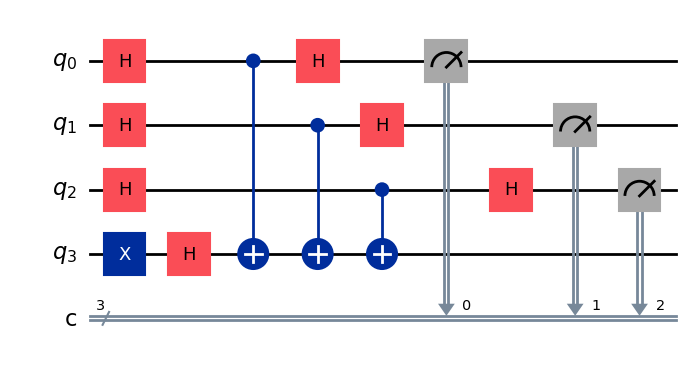

In [ ]:
# Build circuit
n = 3

qc = build_deutsch_jozsa(n, oracle_type="balanced")

qc.draw("mpl")

In [3]:
# Execute
counts = run_circuit(qc)

counts

{'111': 1024}

If the oracle is balanced: { '111': 1024 }

If it is constant: { '000': 1024 }

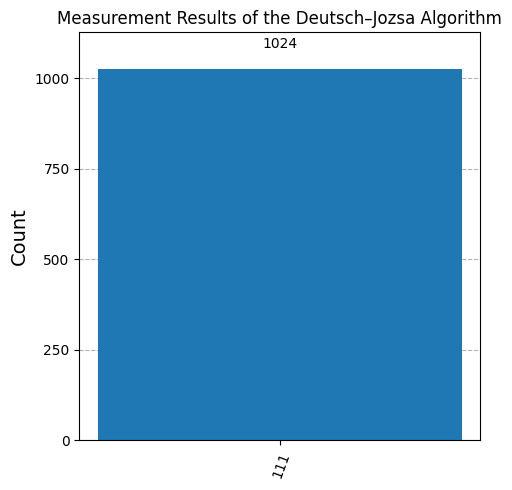

In [6]:
# Plot
plot_histogram(
    counts,
    figsize=(5,5),
    title="Measurement Results of the Deutsch–Jozsa Algorithm",
    bar_labels=True
)

The histogram shows the measurement results of the Deutsch–Jozsa circuit.

The outcome 111 appears with probability 1, indicating that the Boolean function implemented by the oracle is balanced. According to the Deutsch–Jozsa algorithm, a constant function would produce the result 000.

##### Experiment 2: Constant Oracle


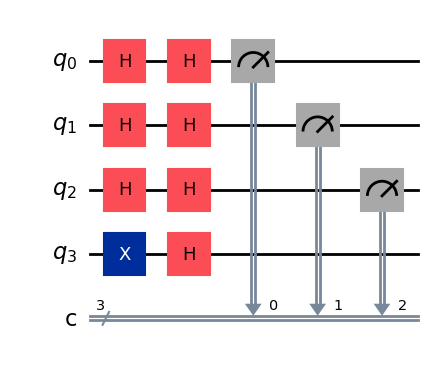

In [7]:
qc_constant = build_deutsch_jozsa(3, oracle_type="constant")

qc_constant.draw("mpl")

In [8]:
counts_constant = run_circuit(qc_constant)

counts_constant

{'000': 1024}

If the oracle is balanced: { '111': 1024 }

If it is constant: { '000': 1024 }

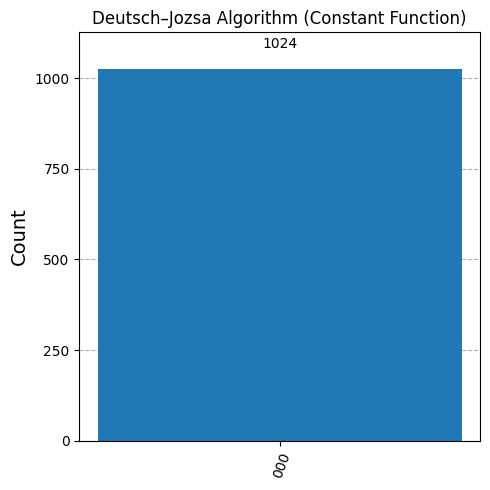

In [10]:
# Plot
plot_histogram(
    counts_constant,
    figsize=(5,5),
    title="Deutsch–Jozsa Algorithm (Constant Function)",
    bar_labels=True
)

The measurement result is 000 with probability 1.

This indicates that the Boolean function implemented by the oracle is constant.

The Deutsch–Jozsa algorithm correctly identifies the nature of the function using a single oracle query.

## Classical vs Quantum Complexity

In [12]:
# Classical and quantum
n_values = np.arange(1,11)

classical_complexity = 2**(n_values-1) + 1
quantum_complexity = np.ones(len(n_values))

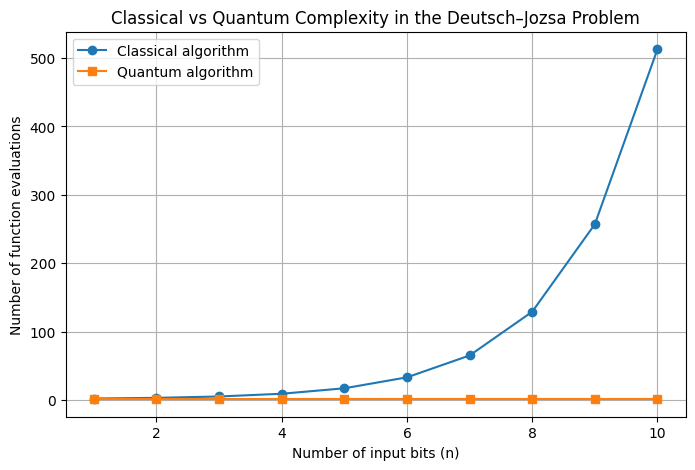

In [17]:
# Plot
plt.figure(figsize=(8,5))

plt.plot(n_values, classical_complexity, marker='o', label="Classical algorithm")
plt.plot(n_values, quantum_complexity, marker='s', label="Quantum algorithm")

plt.xlabel("Number of input bits (n)")
plt.ylabel("Number of function evaluations")
plt.title("Classical vs Quantum Complexity in the Deutsch–Jozsa Problem")

plt.legend()
plt.grid(True)

plt.show()

The plot compares the number of function evaluations required by classical and quantum algorithms to determine whether a Boolean function is constant or balanced.

The classical algorithm requires up to $2^{n-1}+1$ evaluations in the worst case, which grows exponentially with the number of input bits.

In contrast, the Deutsch–Jozsa quantum algorithm solves the problem with a single oracle query regardless of n.

This demonstrates an exponential separation between classical and quantum computation for this problem.